In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

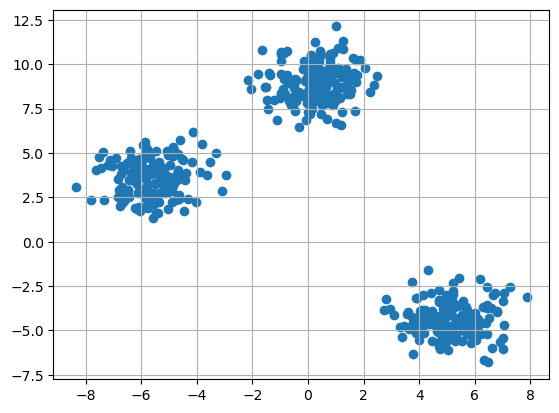

In [2]:
X,y = make_blobs(n_samples = 500,n_features = 2,centers = 3,random_state = 23)

fig = plt.figure(0)
plt.grid(True)
plt.scatter(X[:,0],X[:,1])
plt.show()

In [20]:
X

array([[-1.08899990e+00,  1.44883528e-01],
       [-1.05420498e+00,  4.33461653e-01],
       [-1.10123732e+00,  7.80002582e-02],
       [ 1.43719599e+00, -1.12554682e+00],
       [-1.45695691e+00, -7.38622530e-02],
       [-1.46985571e+00,  6.53728044e-02],
       [-1.51097382e-01,  1.44176860e+00],
       [ 1.41217356e+00, -1.68724969e+00],
       [ 8.41764375e-02,  1.25007291e+00],
       [ 5.37833899e-02,  1.32851512e+00],
       [ 5.93442348e-02,  1.34194884e+00],
       [ 9.24837600e-02,  1.02740016e+00],
       [-1.23941278e+00,  1.98117503e-01],
       [-1.33092948e+00,  1.85315139e-02],
       [-1.39680591e+00,  3.58160481e-01],
       [-1.35162802e+00, -1.56850593e-01],
       [-1.33588134e+00,  3.08662616e-01],
       [ 1.39782220e-01,  1.15647284e+00],
       [-1.17857350e+00,  2.92450453e-01],
       [ 1.02384935e+00, -1.32917536e+00],
       [-3.01638603e-01,  1.21617227e+00],
       [ 1.16571746e+00, -9.89578157e-01],
       [ 2.92964225e-01,  1.53714404e+00],
       [ 2.

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [4]:
k = 3

clusters = {}
np.random.seed(23)

for idx in range(k):
    center = 2*(2*np.random.random((X.shape[1],))-1)
    points = []
    cluster = {
        'center' : center,
        'points' : []
    }
    
    clusters[idx] = cluster
    
clusters

{0: {'center': array([0.06919154, 1.78785042]), 'points': []},
 1: {'center': array([ 1.06183904, -0.87041662]), 'points': []},
 2: {'center': array([-1.11581855,  0.74488834]), 'points': []}}

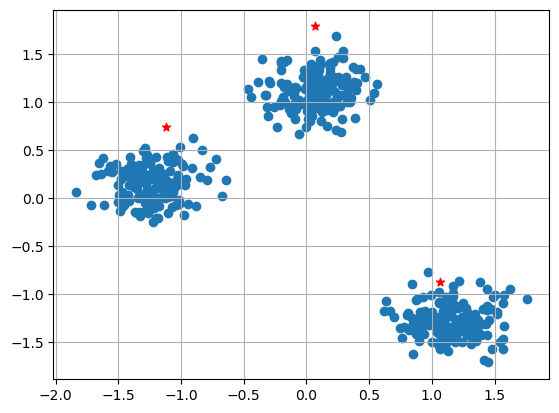

In [5]:
plt.scatter(X[:,0],X[:,1])
plt.grid(True)
for i in clusters:
    center = clusters[i]['center']
    plt.scatter(center[0],center[1],marker = '*',c = 'red')
plt.show()

In [7]:
def distance(p1,p2):
    return np.sqrt(np.sum((p1-p2)**2))

In [8]:
def assign_clusters(X, clusters):
    for idx in range(X.shape[0]):
        dist = []
        
        curr_x = X[idx]
        
        for i in range(k):
            dis = distance(curr_x,clusters[i]['center'])
            dist.append(dis)
        curr_cluster = np.argmin(dist)
        clusters[curr_cluster]['points'].append(curr_x)
    return clusters

def update_clusters(X, clusters):
    for i in range(k):
        points = np.array(clusters[i]['points'])
        if points.shape[0] > 0:
            new_center = points.mean(axis =0)
            clusters[i]['center'] = new_center
            
            clusters[i]['points'] = []
    return clusters

In [9]:
def pred_cluster(X, clusters):
    pred = []
    for i in range(X.shape[0]):
        dist = []
        for j in range(k):
            dist.append(distance(X[i],clusters[j]['center']))
        pred.append(np.argmin(dist))
    return pred

In [10]:
# Repeat until convergence or maximum iterations
max_iters = 100

for _ in range(max_iters):
    old_centers = [clusters[i]['center'].copy() for i in range(k)]

    clusters = assign_clusters(X, clusters)
    clusters = update_clusters(X, clusters)

    new_centers = [clusters[i]['center'] for i in range(k)]

    if np.allclose(old_centers, new_centers):
        break

pred = pred_cluster(X, clusters)

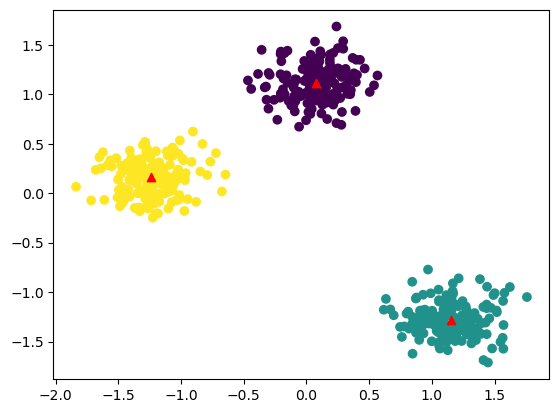

In [11]:
plt.scatter(X[:,0],X[:,1],c = pred)
for i in clusters:
    center = clusters[i]['center']
    plt.scatter(center[0],center[1],marker = '^',c = 'red')
plt.show()

In [13]:
from sklearn.cluster import KMeans
KMeans = KMeans(n_clusters=3)

In [14]:
KMeans.fit(X)

C:\Users\Nasir Hussain\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


KMeans(n_clusters=3)

In [19]:
clusters = KMeans.labels_
clusters

array([2, 2, 2, 1, 2, 2, 0, 1, 0, 0, 0, 0, 2, 2, 2, 2, 2, 0, 2, 1, 0, 1,
       0, 0, 0, 2, 0, 2, 0, 1, 0, 0, 0, 0, 1, 1, 1, 2, 0, 1, 0, 0, 1, 1,
       0, 0, 1, 2, 2, 2, 1, 0, 0, 2, 0, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1, 2,
       2, 2, 1, 1, 1, 1, 2, 2, 0, 1, 1, 1, 1, 0, 2, 0, 2, 0, 0, 1, 0, 2,
       1, 2, 0, 1, 0, 0, 0, 1, 1, 2, 2, 1, 0, 2, 2, 0, 1, 0, 1, 1, 2, 2,
       0, 2, 0, 2, 0, 2, 1, 0, 2, 1, 2, 1, 1, 1, 0, 2, 1, 2, 2, 2, 0, 2,
       2, 2, 1, 1, 2, 1, 2, 0, 1, 0, 0, 2, 0, 1, 1, 2, 2, 2, 0, 2, 0, 2,
       0, 2, 2, 1, 0, 1, 2, 1, 1, 2, 1, 1, 2, 1, 2, 1, 2, 0, 1, 0, 2, 1,
       2, 0, 2, 0, 2, 0, 1, 2, 0, 1, 0, 0, 0, 0, 2, 0, 0, 2, 2, 0, 1, 0,
       2, 2, 2, 0, 1, 2, 1, 1, 1, 0, 1, 2, 1, 2, 0, 2, 1, 0, 2, 1, 1, 1,
       2, 0, 0, 2, 1, 0, 2, 2, 1, 2, 1, 0, 2, 1, 1, 1, 2, 1, 0, 2, 2, 0,
       0, 1, 2, 2, 1, 2, 1, 1, 0, 1, 1, 2, 0, 2, 0, 0, 2, 2, 1, 2, 1, 2,
       0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 2, 0, 0, 2, 0, 0, 0, 0, 0, 2, 2, 1,
       2, 2, 0, 0, 1, 0, 1, 0, 0, 1, 1, 2, 2, 0, 1,

SyntaxError: invalid syntax. Perhaps you forgot a comma? (2848317834.py, line 1)